# asymptotics — Lindstedt–Poincaré Method

Regular perturbation fails for nonlinear oscillators because **secular terms** like $t\sin t$ grow without bound. The Lindstedt–Poincaré method fixes this by introducing a **strained time coordinate**:

$$\tau = \omega(\varepsilon)\,t, \qquad \omega = \omega_0 + \varepsilon\omega_1 + \varepsilon^2\omega_2 + \cdots$$

At each order we choose $\omega_k$ to **eliminate secular terms**, yielding a **uniformly valid** expansion.

The API is identical to `expand_regular` — just call `expand_lindstedt` instead:

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u**3", dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])
sol = eq.expand_lindstedt(order=2)
sol.show()
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sympy import *
from IPython.display import display, Math
from asymptotics import ODE

t_sym   = symbols('t')
tau_sym = symbols('tau')

---
## Example 1 — The Duffing oscillator

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

The Duffing oscillator is the canonical test for Lindstedt. Regular perturbation gives a secular term $t\sin t$ at $\mathcal{O}(\varepsilon)$. Lindstedt eliminates it by finding:

$$\omega_1 = \frac{3}{8} \qquad \Longrightarrow \qquad \omega(\varepsilon) = 1 + \frac{3}{8}\varepsilon - \frac{21}{256}\varepsilon^2 + \cdots$$

The nonlinear spring **stiffens** — the frequency increases with amplitude.

In [2]:
eq = ODE(
    "u'' + u + eps*u**3",
    small_param = "eps",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol = eq.expand_lindstedt(order=2)
sol.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Comparing regular perturbation vs Lindstedt vs exact

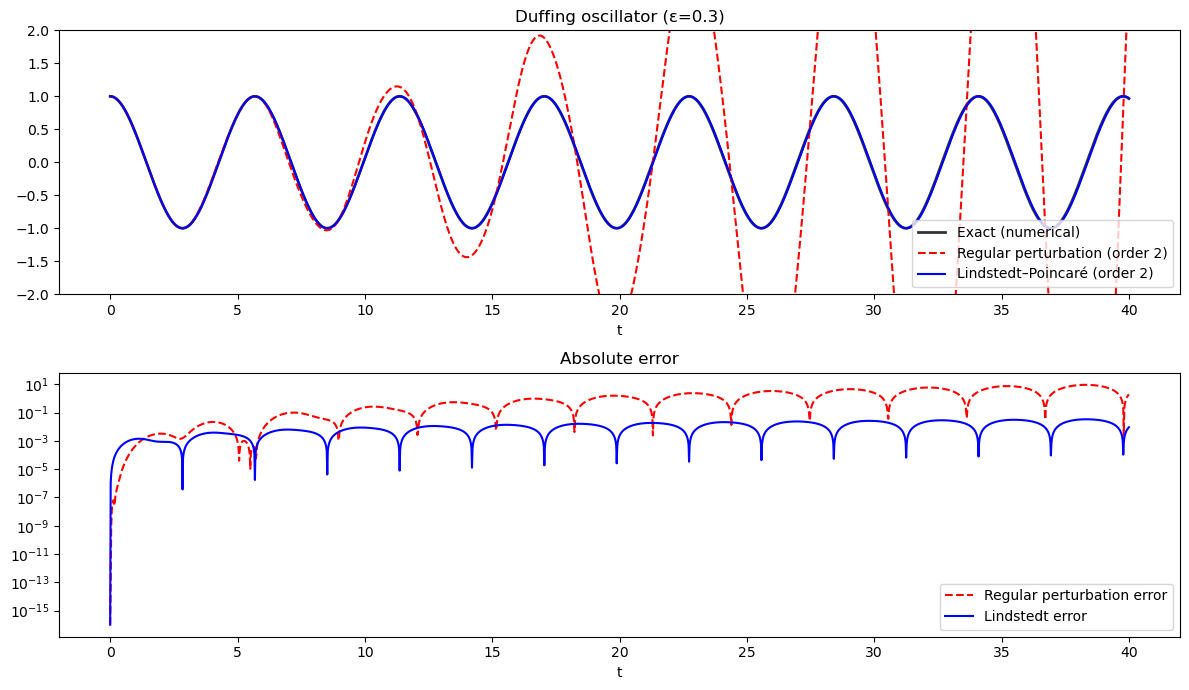

Regular perturbation error at t=40:  1.9568
Lindstedt error at t=40:             0.0091


In [4]:
eps_val = 0.3
t_vals  = np.linspace(0, 40, 2000)

# Numerical (exact)
def rhs_duffing(t, y): return [y[1], -y[0] - eps_val*y[0]**3]
num = solve_ivp(rhs_duffing, [0, 40], [1.0, 0.0], dense_output=True, rtol=1e-12)
u_exact = num.sol(t_vals)[0]

# Regular perturbation (order 2)
sol_reg = eq.expand_regular(order=2)
reg_expr = lambdify(t_sym, sol_reg.composite.subs(sol_reg.small_param, eps_val), 'numpy')
u_reg    = reg_expr(t_vals)

# Lindstedt (order 2)
eps_sym   = sol.small_param
omega_val = float(sol.omega_expansion.subs(eps_sym, eps_val))
lind_expr = lambdify(tau_sym, sol.composite.subs(eps_sym, eps_val), 'numpy')
u_lind    = lind_expr(omega_val * t_vals)
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(t_vals, u_exact, 'k-',  lw=2,   label='Exact (numerical)', alpha=0.8)
axes[0].plot(t_vals, u_reg,   'r--', lw=1.5, label='Regular perturbation (order 2)')
axes[0].plot(t_vals, u_lind,  'b-',  lw=1.5, label='Lindstedt–Poincaré (order 2)')
axes[0].set_title(f'Duffing oscillator (ε={eps_val})')
axes[0].set_xlabel('t'); axes[0].legend()
axes[0].set_ylim(-2, 2)

axes[1].semilogy(t_vals, np.abs(u_exact - u_reg)  + 1e-16, 'r--', label='Regular perturbation error')
axes[1].semilogy(t_vals, np.abs(u_exact - u_lind) + 1e-16, 'b-',  label='Lindstedt error')
axes[1].set_title('Absolute error')
axes[1].set_xlabel('t'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Regular perturbation error at t=40:  {abs(u_exact[-1] - u_reg[-1]):.4f}")
print(f"Lindstedt error at t=40:             {abs(u_exact[-1] - u_lind[-1]):.4f}")

  ℹ️  dependent = 'u' (inferred from conditions), independent = 't' (inferred from equation)
     To override: ODE(..., dependent='u', independent='t')


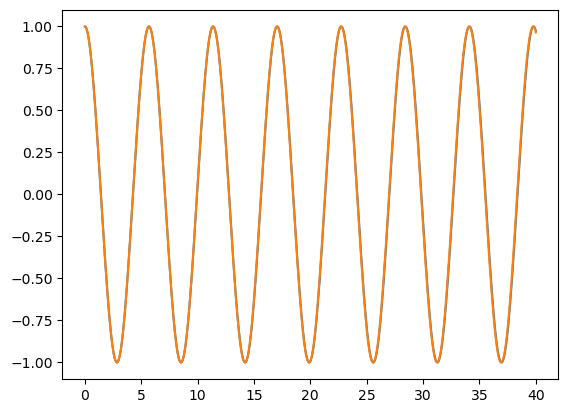

In [10]:
eq = ODE(
    "u'' + u + eps*u**3",
    small_param = "eps",
    conditions  = ["u(0) = 1", "u'(0) = 0"],
)

sol = eq.expand_lindstedt(order=2)

eps_val = 0.3
t_vals  = np.linspace(0, 40, 2000)

# Numerical (exact)
def rhs_duffing(t, y): return [y[1], -y[0] - eps_val*y[0]**3]
num = solve_ivp(rhs_duffing, [0, 40], [1.0, 0.0], dense_output=True, rtol=1e-12)
u_exact = num.sol(t_vals)[0]

plt.plot(t_vals, sol.eval(eps=eps_val,at=t_vals))
plt.plot(t_vals, u_exact)

ValueError: 

  compare_numeric needs the original problem object.


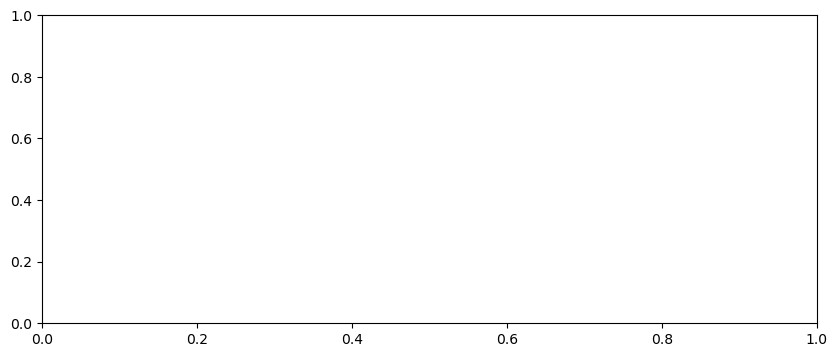

In [3]:
sol.compare_numeric(eps=0.1,plot_range=[0,30]);

### Period accuracy

In [4]:
print(f"{'ε':>8}  {'T numerical':>14}  {'T Lindstedt':>14}  {'T regular':>12}  {'err Lindstedt':>14}")
print("-" * 70)

for ev in [0.05, 0.1, 0.2, 0.3, 0.5]:
    def rhs(t, y): return [y[1], -y[0] - ev*y[0]**3]
    num_loc = solve_ivp(rhs, [0, 30], [1.0, 0.0], dense_output=True, rtol=1e-12)
    t_fine  = np.linspace(0, 20, 5000)
    u_fine  = num_loc.sol(t_fine)[0]
    peaks   = [i for i in range(1, len(u_fine)-1)
               if u_fine[i] > u_fine[i-1] and u_fine[i] > u_fine[i+1]]
    T_num   = t_fine[peaks[1]] - t_fine[peaks[0]] if len(peaks) >= 2 else float('nan')

    omega_l = float(sol.omega_expansion.subs(eps_sym, ev))
    T_lind  = 2*np.pi / omega_l
    T_reg   = 2*np.pi   # regular perturbation gives omega=1 always

    print(f"{ev:>8.2f}  {T_num:>14.6f}  {T_lind:>14.6f}  {T_reg:>12.6f}  {abs(T_num-T_lind):>14.2e}")

       ε     T numerical     T Lindstedt     T regular   err Lindstedt
----------------------------------------------------------------------
    0.05        6.169234        6.168786      6.283185        4.48e-04
    0.10        6.061212        6.060874      6.283185        3.38e-04
    0.20        5.861172        5.862718      6.283185        1.55e-03
    0.30        5.681136        5.685538      6.283185        4.40e-03
    0.50        5.369074        5.384085      6.283185        1.50e-02


---
## Example 2 — Amplitude dependence

$$u'' + u + \varepsilon u^3 = 0, \qquad u(0) = A,\quad u'(0) = 0$$

For a Duffing oscillator with initial amplitude $A$, the frequency correction depends on $A$:
$$\omega_1 = \frac{3A^2}{8}$$
Larger amplitude → higher frequency. This is the hallmark of a **hardening spring**.

In [10]:
eq_A = ODE(
    "u'' + u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = A", "u'(0) = 0"],
)
sol = eq_A.expand_lindstedt(order=2)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

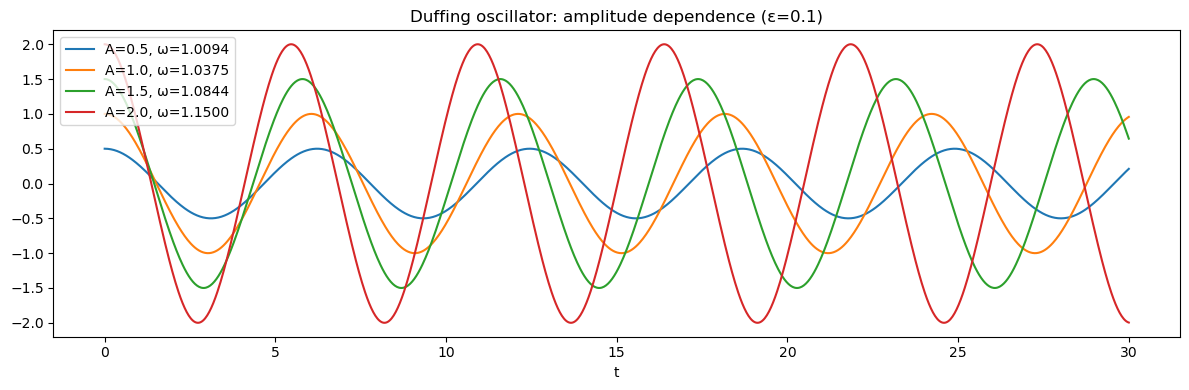

Frequency formula: ω ≈ 1 + (3A²/8)·ε


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
eps_val  = 0.1
t_vals   = np.linspace(0, 30, 1000)

fig, ax = plt.subplots(figsize=(12, 4))

for A in [0.5, 1.0, 1.5, 2.0]:
    eq_A = ODE(
        "u'' + u + eps*u**3",
        dependent="u", small_param="eps", independent="t",
        conditions=[f"u(0) = {A}", "u'(0) = 0"],
    )
    sol_A     = eq_A.expand_lindstedt(order=1)
    omega_A   = float(sol_A.omega_expansion.subs(sol_A.small_param, eps_val))
    lind_expr = lambdify(tau_sym, sol_A.composite.subs(sol_A.small_param, eps_val), 'numpy')
    u_lind    = lind_expr(omega_A * t_vals)

    ax.plot(t_vals, u_lind, label=f'A={A}, ω={omega_A:.4f}')

ax.set_title(f'Duffing oscillator: amplitude dependence (ε={eps_val})')
ax.set_xlabel('t'); ax.legend()
plt.tight_layout()
plt.show()

print("Frequency formula: ω ≈ 1 + (3A²/8)·ε")
for A in [0.5, 1.0, 1.5, 2.0]:
    display(Math(f'A={A}: \\quad \\omega_1 = \\frac{{3 \\times {A}^2}}{{8}} = {3*A**2/8:.4f}'))

---
## Example 3 — Softening spring

$$u'' + u - \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

Flipping the sign of the cubic term gives a **softening spring** — frequency *decreases* with amplitude.
Now $\omega_1 = -3/8$.

In [8]:
eq_soft = ODE(
    "u'' + u - eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"],
)

sol_soft = eq_soft.expand_lindstedt(order=2)
sol_soft.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

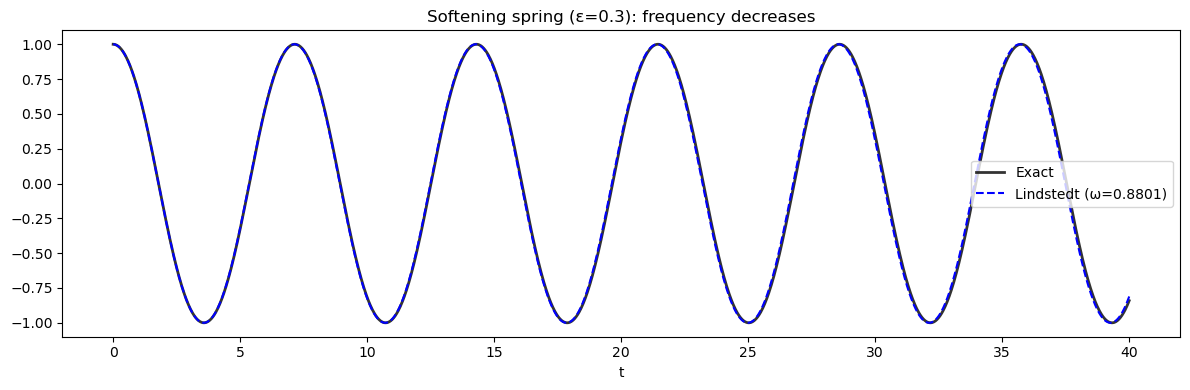

<IPython.core.display.Math object>

In [9]:
eps_val = 0.3
t_vals  = np.linspace(0, 40, 2000)

def rhs_soft(t, y): return [y[1], -y[0] + eps_val*y[0]**3]
num_soft = solve_ivp(rhs_soft, [0, 40], [1.0, 0.0], dense_output=True, rtol=1e-12)
u_exact  = num_soft.sol(t_vals)[0]

eps_sym_soft = sol_soft.small_param
omega_soft   = float(sol_soft.omega_expansion.subs(eps_sym_soft, eps_val))
lind_expr    = lambdify(tau_sym, sol_soft.composite.subs(eps_sym_soft, eps_val), 'numpy')
u_lind       = lind_expr(omega_soft * t_vals)

plt.figure(figsize=(12, 4))
plt.plot(t_vals, u_exact, 'k-',  lw=2,   label='Exact', alpha=0.8)
plt.plot(t_vals, u_lind,  'b--', lw=1.5, label=f'Lindstedt (ω={omega_soft:.4f})')
plt.title(f'Softening spring (ε={eps_val}): frequency decreases')
plt.xlabel('t'); plt.legend()
plt.tight_layout()
plt.show()

display(Math(f'\\omega(\\varepsilon={eps_val}) = ' + latex(sol_soft.omega_expansion) +
             f' = {omega_soft:.6f}'))

---
## Example 4 — Nonzero $\omega_0$: the 2ω oscillator

$$u'' + 4u + \varepsilon u^3 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

Here $\omega_0 = 2$ — asymptotics detects this automatically. The strained time absorbs $\omega_0$, so in $\tau$-space the solution still has period $2\pi$.

In [11]:
eq4 = ODE(
    "u'' + 4*u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"],
)

sol4 = eq4.expand_lindstedt(order=2)
sol4.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Detected ω₀ = 2  (expected 2)
ω(ε) = 2

At ε=0.2: ω = 2.000000,  T = 3.141593


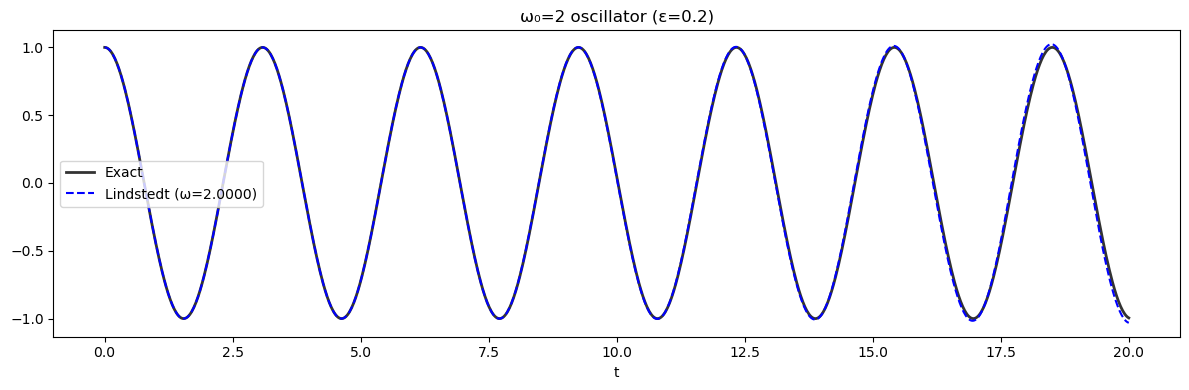

In [12]:
print(f'Detected ω₀ = {sol4.omega_0}  (expected 2)')
print(f'ω(ε) = {sol4.omega_expansion}')

# Physical period T = 2π/omega
eps_val  = 0.2
eps_sym4 = sol4.small_param
omega4   = float(sol4.omega_expansion.subs(eps_sym4, eps_val))
print(f'\nAt ε={eps_val}: ω = {omega4:.6f},  T = {2*np.pi/omega4:.6f}')

# Numerical verification
t_vals = np.linspace(0, 20, 1000)
def rhs4(t, y): return [y[1], -4*y[0] - eps_val*y[0]**3]
num4   = solve_ivp(rhs4, [0, 20], [1.0, 0.0], dense_output=True, rtol=1e-12)
u_exact4 = num4.sol(t_vals)[0]
lind4    = lambdify(tau_sym, sol4.composite.subs(eps_sym4, eps_val), 'numpy')
u_lind4  = lind4(omega4 * t_vals)

plt.figure(figsize=(12, 4))
plt.plot(t_vals, u_exact4, 'k-',  lw=2,   label='Exact', alpha=0.8)
plt.plot(t_vals, u_lind4,  'b--', lw=1.5, label=f'Lindstedt (ω={omega4:.4f})')
plt.title(f'ω₀=2 oscillator (ε={eps_val})')
plt.xlabel('t'); plt.legend()
plt.tight_layout()
plt.show()

---
## Example 5 — Quadratic nonlinearity

$$u'' + u + \varepsilon u^2 = 0, \qquad u(0) = 1,\quad u'(0) = 0$$

A quadratic nonlinearity — $\omega_1 = 0$ at first order (quadratic terms don't shift the frequency at O(ε)). The frequency correction first appears at $\mathcal{O}(\varepsilon^2)$.

In [13]:
eq5 = ODE(
    "u'' + u + eps*u**2",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"],
)

sol5 = eq5.expand_lindstedt(order=2)
sol5.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:
print('Frequency corrections:')
print(f'  ω₁ = {sol5[1].omega_k_val}  (zero — quadratic nonlinearity shifts at O(ε²))')
print(f'  ω₂ = {sol5[2].omega_k_val}')
print(f'  ω(ε) = {sol5.omega_expansion}')

Frequency corrections:
  ω₁ = 0  (zero — quadratic nonlinearity shifts at O(ε²))
  ω₂ = -5/12
  ω(ε) = 1 - 5*eps**2/12


---
## Example 6 — Higher order: order 3

Going to order 3 on the Duffing oscillator reveals the next frequency correction. With asymptotics this is now fast.

In [15]:
import time

eq = ODE(
    "u'' + u + eps*u**3",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u'(0) = 0"],
)

t0  = time.time()
sol = eq.expand_lindstedt(order=3)
print(f'Order 3 computed in {time.time()-t0:.2f}s')
sol.show()

Order 3 computed in 0.30s


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [16]:
# Period accuracy improves at order 3
eps_sym = sol.small_param
print(f"{'ε':>8}  {'T numerical':>14}  {'T order 2':>12}  {'T order 3':>12}")
print("-" * 55)

sol2 = eq.expand_lindstedt(order=2)

for ev in [0.1, 0.2, 0.3, 0.5]:
    def rhs(t, y): return [y[1], -y[0] - ev*y[0]**3]
    num_loc = solve_ivp(rhs, [0, 30], [1.0, 0.0], dense_output=True, rtol=1e-12)
    t_fine  = np.linspace(0, 20, 5000)
    u_fine  = num_loc.sol(t_fine)[0]
    peaks   = [i for i in range(1, len(u_fine)-1)
               if u_fine[i] > u_fine[i-1] and u_fine[i] > u_fine[i+1]]
    T_num   = t_fine[peaks[1]] - t_fine[peaks[0]]

    o2 = float(sol2.omega_expansion.subs(eps_sym, ev))
    o3 = float(sol.omega_expansion.subs(eps_sym, ev))

    print(f"{ev:>8.2f}  {T_num:>14.6f}  {2*np.pi/o2:>12.6f}  {2*np.pi/o3:>12.6f}")

       ε     T numerical     T order 2     T order 3
-------------------------------------------------------
    0.10        6.061212      6.060874      6.060643
    0.20        5.861172      5.862718      5.860988
    0.30        5.681136      5.685538      5.680049
    0.50        5.369074      5.384085      5.361372


---
## API quick reference

```python
from asymptotics import ODE

eq  = ODE("u'' + u + eps*u**3",
          dependent="u", small_param="eps", independent="t",
          conditions=["u(0) = 1", "u'(0) = 0"])

sol = eq.expand_lindstedt(order=2)

# Display
sol.show()                          # full hierarchy (LaTeX in Jupyter)

# Frequency
sol.omega_0                         # ω₀ — auto-detected
sol.omega_expansion                 # ω(ε) = ω₀ + ω₁·ε + ω₂·ε² + ...
sol[k].omega_k_val                  # ωₖ — frequency correction at order k
sol[k].secularity_condition         # Eq(secular_coeff, 0)

# Solution
sol[k].particular_solution         # uₖ(τ) — secular-free
sol.composite                       # u(τ, ε)
sol.composite_t                     # u(t, ε) with τ = ω(ε)·t substituted
sol.tau                             # the τ symbol

# Evaluate at specific ε
eps_sym   = sol.small_param
omega_val = float(sol.omega_expansion.subs(eps_sym, 0.1))
u_func    = lambdify(tau_sym, sol.composite.subs(eps_sym, 0.1), 'numpy')
u_at_t    = u_func(omega_val * t_array)   # u(t) from τ = ω·t
```

**Requirements:** `expand_lindstedt` works for 2nd-order oscillators of the form
$u'' + \omega_0^2 u + \varepsilon f(u, u') = 0$. The natural frequency $\omega_0$ is detected automatically.

In [3]:
eq = ODE(
    "u'' + eps*u**2",
    dependent="u", small_param="eps", independent="t",
    conditions=["u(0) = 1", "u(1) = 0"],
)

# t0  = time.time()
sol = eq.expand_lindstedt(order=1)
# print(f'Order 3 computed in {time.time()-t0:.2f}s')
sol.show()

ValueError: 

  Lindstedt–Poincaré does not apply to BVPs.
  The method requires all conditions at t=0 (IVP).

  For BVPs with nonlinear oscillations, consider
  expand_regular() instead, or reformulate as an IVP.
